## Get started
This tutorial will show you how asynctorch can be used with simple spiking CNNs. Make sure asynctorch, snnTorch and tonic have been installed! Tonic is not an automatic dependency of asynctorch because it is not required for all use cases. For CUDA support, make sure you have a working CUDA installation and the correct version of PyTorch installed.

### Import packages

In [1]:
import torch
import tonic
import matplotlib.pyplot as plt
import tonic.transforms as transforms
from asynctorch.simulator.async_simulator import AsyncSimulator
from asynctorch.nn.architecture.conv2d_architecture import Conv2dArchitecture, Conv2dParams
from asynctorch.nn.neuron.lif_state import LIFState
from asynctorch.simulator.extensions.spike_dropout_extension import SpikeDropoutExtension
from snntorch import surrogate
from asynctorch.simulator.spike_scheduler import RandomSpikeScheduler
from asynctorch.simulator.spike_selector import SpikeSelector
from torch.utils.data import DataLoader
from tqdm import tqdm
import snntorch.functional as SF
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/home/roel/asynctorch/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


### Load data

In [2]:
timestep_size = 10000
transform = transforms.ToFrame(sensor_size=tonic.datasets.NMNIST.sensor_size, time_window=timestep_size)
train_dataset = tonic.datasets.NMNIST(save_to="./data", transform=transform, train=True, first_saccade_only=True)
collate_fn = tonic.collation.PadTensors(batch_first=False)

### Define the network and parameters for simulator
Network architecture: 2 convolutional layers, then fully-connected  
Spike dropout will be used for regularization. This is not directly included in the architecture, but rather added as an extension.

In [3]:
# Network architecture
n_outputs = 10
neurons_per_layer = [256, 128, 32, n_outputs]
conv_params_per_layer = [
        Conv2dParams(in_channels=2, out_channels=4, kernel_size=5, stride=4, padding=0),
        Conv2dParams(in_channels=4, out_channels=8, kernel_size=3, stride=2, padding=1),
        Conv2dParams(in_channels=8, out_channels=32, kernel_size=3, stride=2, padding=0),
]
n_neurons = sum(neurons_per_layer)
network_module = Conv2dArchitecture(2, 34, 34, neurons_per_layer, conv_params_per_layer, device)
input_dropout = SpikeDropoutExtension(p=0.25, apply_to_input=True, apply_to_network=False)

# Neuron model
spike_grad = surrogate.atan()
state_module = LIFState(
    neurons_per_layer,
    tau_m=1000,
    membrane_threshold=0.3,
    sync_threshold=0.0,
    spike_grad=spike_grad,
    sync_grad=spike_grad,
    device=device,
    refrac_dropout=0.8
)

# Simulator
spike_scheduler = RandomSpikeScheduler(state_module)
spike_selector_module = SpikeSelector(
    network_module,
    spike_scheduler,
    forward_group_size=16,
    device=device,
    prioritize_input=True,
)

## Start training
For training, we use the standard PyTorch training loop with some snnTorch specific functions. Instead of calling a forward pass on the network, we call the forward function of the simulator. This function takes the input data and the time step, and returns the output spikes of the network. The output spikes can then be used to calculate the loss and update the weights of the network.

In [4]:
async_simulator = AsyncSimulator(state_module, spike_selector_module, forward_step_extensions=[input_dropout])
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)
async_simulator.train()
n_epochs = 5
optimizer = torch.optim.Adam(async_simulator.parameters(), lr=5e-4)
loss_fn = SF.ce_rate_loss()
accuracy_function = SF.accuracy_rate

losses = []
accuracies = []
for epoch in range(n_epochs):
    batch_iter = iter(train_dataloader)
    for data, targets in tqdm(batch_iter):
        data = data.to(device)
        targets = targets.to(device)
        async_simulator.reset_state()

        # Forward pass
        ys = []
        for t in range(data.shape[0]):
            ts_data = data[t].view(data[t].shape[0], -1)
            spk_out = async_simulator(ts_data, dt=timestep_size)[:, n_neurons-n_outputs:]
            ys.append(spk_out) 
        y = torch.stack(ys)
        loss = loss_fn(y, targets)
        losses.append(loss.item())
        accuracy = accuracy_function(y, targets)
        accuracies.append(accuracy)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

100%|██████████| 235/235 [00:26<00:00,  8.87it/s]


### Check training progress

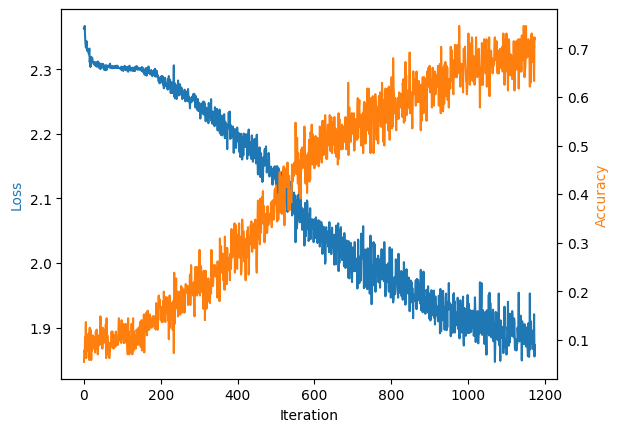

In [5]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(losses, color='C0')
ax2.plot(accuracies, color='C1')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss', color='C0')
ax2.set_ylabel('Accuracy', color='C1')

plt.show()

### Export the trained model
The trained weights are kept in the simulator. We can use the standard PyTorch functions to save the weights of the network.

In [ ]:
torch.save(async_simulator.state_dict(), "./nmnist_cnn_asynctorch.pt")